# Parameter Sweep: $\alpha$-Attractor T-Model ($\alpha$ vs $n$)

$V=V_0\tanh^{2n}(\phi/\sqrt{6\alpha})$ -- the Kallosh-Linde $\alpha$-attractor T-model. This single family lets us test a **legitimate, literature-recognized** scale-vs-shape pair within the same functional form:

- **$\alpha$ (SCALE-type):** fix $n=1$, vary $\alpha$ -- purely rescales $\phi/\sqrt{6\alpha}$, shape function $\tanh^2(x)$ held fixed.
- **$n$ (SHAPE-type):** fix $\alpha=1$, vary $n$ -- changes the functional form itself.

In [1]:
import numpy as np
from scipy import integrate
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

def background_eqn(N, fields, potential):
    phi, dphidN = fields
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN \
               - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    return [dphidN, d2phidN2]

def Hubble(phi_N, V):
    return np.sqrt(V/(3 - 0.5*(phi_N*phi_N)))

def epsilon1(phi_N):
    return 0.5*phi_N*phi_N

def stop_integration(N, y):
    return 0.5*(y[1]**2) - 1
stop_integration.terminal = True
stop_integration.direction = 0

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

def z_of(a, phi_N):
    return a*phi_N

def solve_background(potential, ph_initial, t_end=120.0, fine_step=2e-3):
    efolds_fine = np.arange(0, t_end, fine_step)
    sol = solve_ivp(lambda N, y: background_eqn(N, y, potential),
                     [0, t_end], ph_initial, method='RK45',
                     dense_output=True, events=(stop_integration,), max_step=np.inf)
    Nend = sol.t_events[0][0] if len(sol.t_events[0]) > 0 else sol.t[-1]
    mask = efolds_fine < Nend
    efolds = efolds_fine[mask]
    y = sol.sol(efolds)
    phi, dphi = y[0], y[1]
    pot, dpotdphi = potential(phi)
    Hub = Hubble(dphi, pot)
    return dict(efolds=efolds, phi=phi, dphi=dphi, pot=pot,
                dpotdphi=dpotdphi, Hub=Hub, Nend=Nend)

def pert_eqn(y, N, k, ai, potential):
    phi, dphidN, Rk_re, Rk_re_N, Rk_im, Rk_im_N, hk_re, hk_re_N, hk_im, hk_im_N = y
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    a = ai*np.exp(N)
    H = np.sqrt(v/(3 - 0.5*(dphidN*dphidN)))
    zN = a*(dphidN + d2phidN2)
    zval = z_of(a, dphidN)
    Rk_re_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_re_N - ((k/(a*H))**2)*Rk_re
    Rk_im_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_im_N - ((k/(a*H))**2)*Rk_im
    hk_re_NN = -(3 - (dphidN**2)*0.5)*hk_re_N - ((k/(a*H))**2)*hk_re
    hk_im_NN = -(3 - (dphidN**2)*0.5)*hk_im_N - ((k/(a*H))**2)*hk_im
    return [dphidN, d2phidN2, Rk_re_N, Rk_re_NN, Rk_im_N, Rk_im_NN,
            hk_re_N, hk_re_NN, hk_im_N, hk_im_NN]

def boundary(k, t, aH, Nic_cond, Nshs_cond):
    ic_diff = k - Nic_cond*aH
    shs_diff = k - Nshs_cond*aH
    idx_ic, _ = find_nearest(ic_diff, 0)
    idx_shs, _ = find_nearest(shs_diff, 0)
    return idx_ic, t[idx_ic], t[idx_shs]

def initial_condition(idx_ic, k, efolds, phi, dphi, ai, Hub, potential):
    phi_ic = phi[idx_ic]; phiN_ic = dphi[idx_ic]
    a_ic = ai*np.exp(efolds[idx_ic]); z_ic = z_of(a_ic, phiN_ic); H_ic = Hub[idx_ic]
    _, phiNN_ic = background_eqn(efolds[idx_ic], [phi_ic, phiN_ic], potential)
    Rk_re_ic = (1/(np.sqrt(2*k)))/z_ic
    Rk_im_ic = 0
    Rk_re_N_ic = -Rk_re_ic*((phiNN_ic/phiN_ic) + 1)
    Rk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*z_ic)
    hk_re_ic = (1/(np.sqrt(2*k)))/a_ic
    hk_im_ic = 0
    hk_re_N_ic = -hk_re_ic
    hk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*a_ic)
    return [phi_ic, phiN_ic, Rk_re_ic, Rk_re_N_ic, Rk_im_ic, Rk_im_N_ic,
            hk_re_ic, hk_re_N_ic, hk_im_ic, hk_im_N_ic]

def Psk(kk, Rk):
    Rk_re, Rk_im = Rk
    return kk**3/(2e0*np.pi**2)*((Rk_re*Rk_re)+(Rk_im*Rk_im))

def Pth(kk, hk):
    hk_re, hk_im = hk
    return 8.0*kk**3/(2e0*np.pi**2)*((hk_re*hk_re)+(hk_im*hk_im))

class InflationRun:
    def __init__(self, potential, bg, kpivot=0.05, Nic_cond=100, Nshs_cond=1e-5):
        self.potential = potential
        self.efolds = bg['efolds']; self.phi = bg['phi']; self.dphi = bg['dphi']
        self.Hub = bg['Hub']; self.Nend = bg['Nend']
        self.Nic_cond = Nic_cond; self.Nshs_cond = Nshs_cond
        idx50, Ne50 = find_nearest(self.efolds, self.Nend - 50)
        self.idx50, self.Ne50 = idx50, Ne50
        self.ai = kpivot/(np.exp(Ne50)*self.Hub[idx50])
        self.kpivot = kpivot

    def compute_pps(self, kk, atol=1e-11):
        idx_ic, Nic, Nshs = boundary(kk, self.efolds, self.ai*np.exp(self.efolds)*self.Hub,
                                      self.Nic_cond, self.Nshs_cond)
        efolds_pert = np.arange(Nic, Nshs, 0.01)
        pert_ic = initial_condition(idx_ic, kk, self.efolds, self.phi, self.dphi,
                                     self.ai, self.Hub, self.potential)
        sol_pert = integrate.odeint(pert_eqn, pert_ic, efolds_pert,
                                     args=(kk, self.ai, self.potential), atol=atol)
        Rkshs = [sol_pert[-1,2], sol_pert[-1,4]]
        hkshs = [sol_pert[-1,6], sol_pert[-1,8]]
        return Psk(kk, Rkshs), Pth(kk, hkshs), efolds_pert, sol_pert, Nic, Nshs


In [2]:
def tmodel_potential(phi, alpha, n, V0=1e-11):
    lam = 1.0/np.sqrt(6*alpha)
    x = lam*phi
    t = np.tanh(x)
    v = V0*t**(2*n)
    dv = V0*2*n*t**(2*n-1)*(1-t**2)*lam
    return v, dv

def eps_eta_tmodel(phi, alpha, n):
    lam = 1.0/np.sqrt(6*alpha)
    x = lam*phi
    t = np.tanh(x)
    eps_v = 0.5*(2*n*lam*(1-t**2)/t)**2
    eta_v = 2*n*lam**2*(1-t**2)*((2*n-1)-(2*n+1)*t**2)/t**2
    return eps_v, eta_v

def verify(phi_test, alpha, n):
    h = 1e-6
    pot = lambda phi: tmodel_potential(phi, alpha, n)
    V0,dV0 = pot(phi_test)
    Vp,_ = pot(phi_test+h); Vm,_ = pot(phi_test-h)
    d2V_fd = (Vp - 2*V0 + Vm)/h**2
    eps_a, eta_a = eps_eta_tmodel(phi_test, alpha, n)
    print(f'alpha={alpha}, n={n}, phi={phi_test}: eps analytic={eps_a:.6f} fd={0.5*(dV0/V0)**2:.6f} | '
          f'eta analytic={eta_a:.6f} fd={d2V_fd/V0:.6f}')

verify(3.0, 1.0, 1.0)
verify(3.0, 1.0, 2.0)
verify(5.0, 3.0, 1.0)
verify(2.0, 0.5, 3.0)

alpha=1.0, n=1.0, phi=3.0: eps analytic=0.040355 fd=0.040355 | eta analytic=-0.154737 fd=-0.154624
alpha=1.0, n=2.0, phi=3.0: eps analytic=0.161420 fd=0.161420 | eta analytic=-0.148053 fd=-0.147397
alpha=3.0, n=1.0, phi=5.0: eps analytic=0.016234 fd=0.016234 | eta analytic=-0.054011 fd=-0.053861
alpha=0.5, n=3.0, phi=2.0: eps analytic=0.965966 fd=0.965966 | eta analytic=0.294988 fd=0.295914


In [3]:
TARGET_NEND = 65.0

def calibrate_ns_r(pot, eps_eta_fn, phi_i_guess_lo, phi_i_guess_hi):
    def Nend_of_phi(phi_i):
        ph=[phi_i, None]; V,dV = pot(phi_i); ph[1]=-dV/V
        return solve_background(pot, ph, t_end=150, fine_step=2e-3)['Nend']
    phi_i = brentq(lambda p: Nend_of_phi(p)-TARGET_NEND, phi_i_guess_lo, phi_i_guess_hi, xtol=1e-7)
    ph=[phi_i, None]; V,dV = pot(phi_i); ph[1]=-dV/V
    bg = solve_background(pot, ph, t_end=150, fine_step=5e-4)
    run = InflationRun(pot, bg, kpivot=0.05, Nic_cond=100)
    phi_star = bg['phi'][run.idx50]
    eps_v, eta_v = eps_eta_fn(phi_star)
    ns = 1 - 6*eps_v + 2*eta_v
    r = 16*eps_v
    return phi_i, ns, r

def r2(x, y):
    coef = np.polyfit(x, y, 1); pred = np.polyval(coef, x)
    return 1 - np.sum((y-pred)**2)/np.sum((y-np.mean(y))**2)

## Section A -- SCALE-type: fix $n=1$, sweep $\alpha$

In [4]:
alpha_values = np.array([0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 50.0])
results_alpha = []
for alpha in alpha_values:
    pot = lambda phi: tmodel_potential(phi, alpha, 1.0)
    eps_eta = lambda phi: eps_eta_tmodel(phi, alpha, 1.0)
    guess = 3*np.sqrt(6*alpha)
    phi_i, ns, r = calibrate_ns_r(pot, eps_eta, 0.1, guess*2)
    results_alpha.append(dict(alpha=alpha, phi_i=phi_i, ns=ns, r=r))
    print(f'alpha={alpha}: phi_i={phi_i:.5f}  ns={ns:.4f}  r={r:.6f}')

alpha=0.5: phi_i=5.05231  ns=0.9590  r=0.002484


/tmp/ipykernel_510/2136910039.py:15: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(V/(3 - 0.5*(phi_N*phi_N)))


alpha=1.0: phi_i=6.30541  ns=0.9591  r=0.004871


alpha=2.0: phi_i=7.73950  ns=0.9592  r=0.009417


alpha=3.0: phi_i=8.64473  ns=0.9592  r=0.013695


...

alpha=10.0: phi_i=11.41556  ns=0.9594  r=0.037935


alpha=15.0: phi_i=12.28953  ns=0.9594  r=0.050869


alpha=20.0: phi_i=12.86394  ns=0.9594  r=0.061348


alpha=30.0: phi_i=13.59021  ns=0.9595  r=0.077295


alpha=50.0: phi_i=14.34492  ns=0.9595  r=0.097642


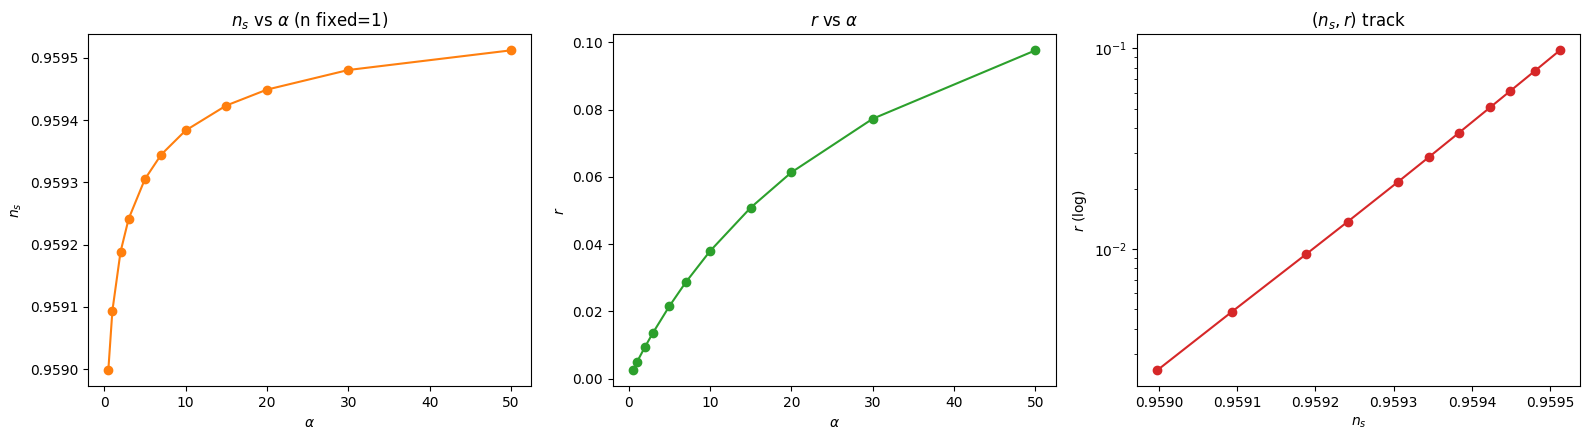

R^2 log-linear:   0.9999
R^2 plain-linear: 0.8039


In [5]:
alphas = [x['alpha'] for x in results_alpha]
ns_a = np.array([x['ns'] for x in results_alpha])
r_a = np.array([x['r'] for x in results_alpha])

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
axes[0].plot(alphas, ns_a, 'o-', color='C1'); axes[0].set_xlabel(r'$\alpha$'); axes[0].set_ylabel('$n_s$')
axes[0].set_title(r'$n_s$ vs $\alpha$ (n fixed=1)')
axes[1].plot(alphas, r_a, 'o-', color='C2'); axes[1].set_xlabel(r'$\alpha$'); axes[1].set_ylabel('$r$')
axes[1].set_title(r'$r$ vs $\alpha$')
axes[2].plot(ns_a, r_a, 'o-', color='C3'); axes[2].set_yscale('log')
axes[2].set_xlabel('$n_s$'); axes[2].set_ylabel('$r$ (log)'); axes[2].set_title('$(n_s,r)$ track')
plt.tight_layout(); plt.show()

print(f'R^2 log-linear:   {r2(ns_a, np.log(r_a)):.4f}')
print(f'R^2 plain-linear: {r2(ns_a, r_a):.4f}')

## Section B -- SHAPE-type: fix $\alpha=1$, sweep $n$

In [6]:
n_values = np.array([0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0])
results_n = []
for n in n_values:
    pot = lambda phi: tmodel_potential(phi, 1.0, n)
    eps_eta = lambda phi: eps_eta_tmodel(phi, 1.0, n)
    phi_i, ns, r = calibrate_ns_r(pot, eps_eta, 0.1, 9.0)
    results_n.append(dict(n=n, phi_i=phi_i, ns=ns, r=r))
    print(f'n={n}: phi_i={phi_i:.5f}  ns={ns:.4f}  r={r:.6f}')

n=0.5: phi_i=5.46871  ns=0.9596  r=0.004748


/tmp/ipykernel_510/2136910039.py:15: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(V/(3 - 0.5*(phi_N*phi_N)))
/tmp/ipykernel_510/3047142533.py:5: RuntimeWarning: invalid value encountered in scalar power
  v = V0*t**(2*n)
/tmp/ipykernel_510/3047142533.py:6: RuntimeWarning: invalid value encountered in scalar power
  dv = V0*2*n*t**(2*n-1)*(1-t**2)*lam


n=0.75: phi_i=5.95685  ns=0.9593  r=0.004832


n=1.0: phi_i=6.30541  ns=0.9591  r=0.004871


n=1.5: phi_i=6.79882  ns=0.9590  r=0.004903


...

n=2.5: phi_i=7.42258  ns=0.9589  r=0.004922


n=3.0: phi_i=7.64552  ns=0.9589  r=0.004926


n=4.0: phi_i=7.99750  ns=0.9588  r=0.004930


n=5.0: phi_i=8.27064  ns=0.9588  r=0.004931


n=7.0: phi_i=8.68259  ns=0.9588  r=0.004933


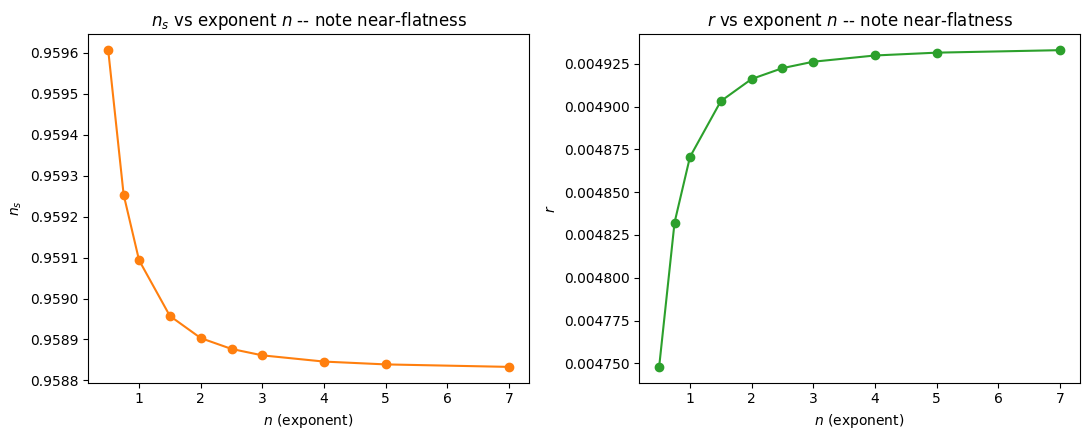

n_s range: 0.9588331277699603 - 0.9596062132697832   (variation: 0.000773085499822912 )
r range:   0.004747962742891204 - 0.004932946014440729   (variation: 0.00018498327154952473 )

This is the well-known alpha-attractor UNIVERSALITY: for fixed alpha, predictions
are nearly independent of the exponent n -- a third, distinct shape-type behavior
(neither a clean line, nor non-monotonic -- just insensitive).


In [7]:
ns_param = [x['n'] for x in results_n]
ns_n = np.array([x['ns'] for x in results_n])
r_n = np.array([x['r'] for x in results_n])

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
axes[0].plot(ns_param, ns_n, 'o-', color='C1'); axes[0].set_xlabel('$n$ (exponent)'); axes[0].set_ylabel('$n_s$')
axes[0].set_title('$n_s$ vs exponent $n$ -- note near-flatness')
axes[1].plot(ns_param, r_n, 'o-', color='C2'); axes[1].set_xlabel('$n$ (exponent)'); axes[1].set_ylabel('$r$')
axes[1].set_title('$r$ vs exponent $n$ -- note near-flatness')
plt.tight_layout(); plt.show()

print('n_s range:', ns_n.min(), '-', ns_n.max(), '  (variation:', ns_n.max()-ns_n.min(), ')')
print('r range:  ', r_n.min(), '-', r_n.max(), '  (variation:', r_n.max()-r_n.min(), ')')
print()
print('This is the well-known alpha-attractor UNIVERSALITY: for fixed alpha, predictions')
print('are nearly independent of the exponent n -- a third, distinct shape-type behavior')
print('(neither a clean line, nor non-monotonic -- just insensitive).')